In [24]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics
print("All libraries imported successfully")

All libraries imported successfully


In [25]:
#importing the dataset
df = pd.read_csv('bitcoin.csv')
df.head()

#column names
print(df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [26]:
df.shape

(2713, 7)

In [27]:
#statistical summary of the dataset
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [28]:
df.info()
#information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


Performing Exploratory Data Analysis on the dataset

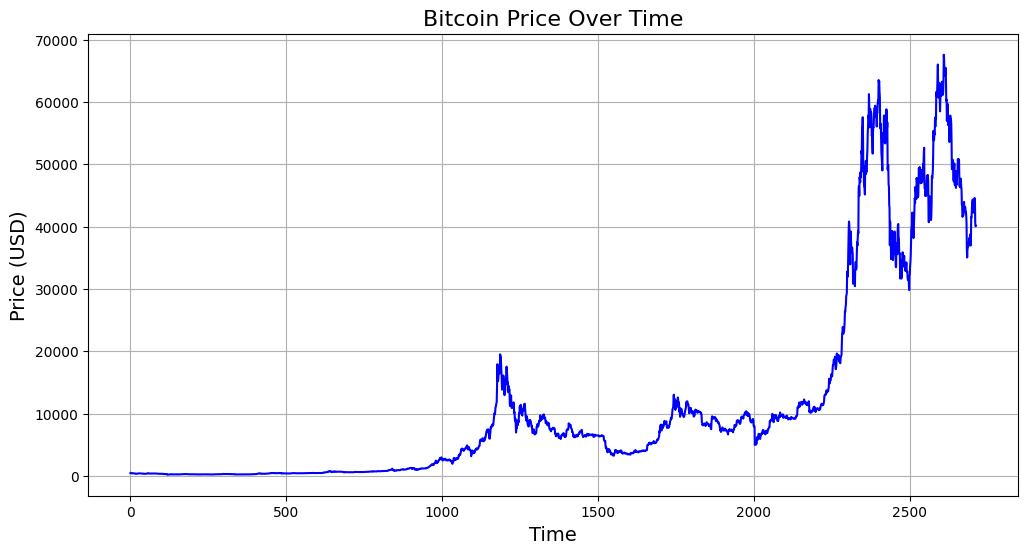

In [29]:
#how is the price of the crytocurrency changing over time?
plt.figure(figsize=(12,6))
plt.plot(df['Close'], color='blue')
plt.title('Bitcoin Price Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.grid()
plt.show()


In [30]:
df[df['Close'] == df['Adj Close']].shape
df.shape
#shape of both the parameters have the same shape


(2713, 7)

In [31]:
#dropping adj close 
df = df.drop('Adj Close', axis=1)


In [32]:
#null  values count
df.isnull().sum()


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

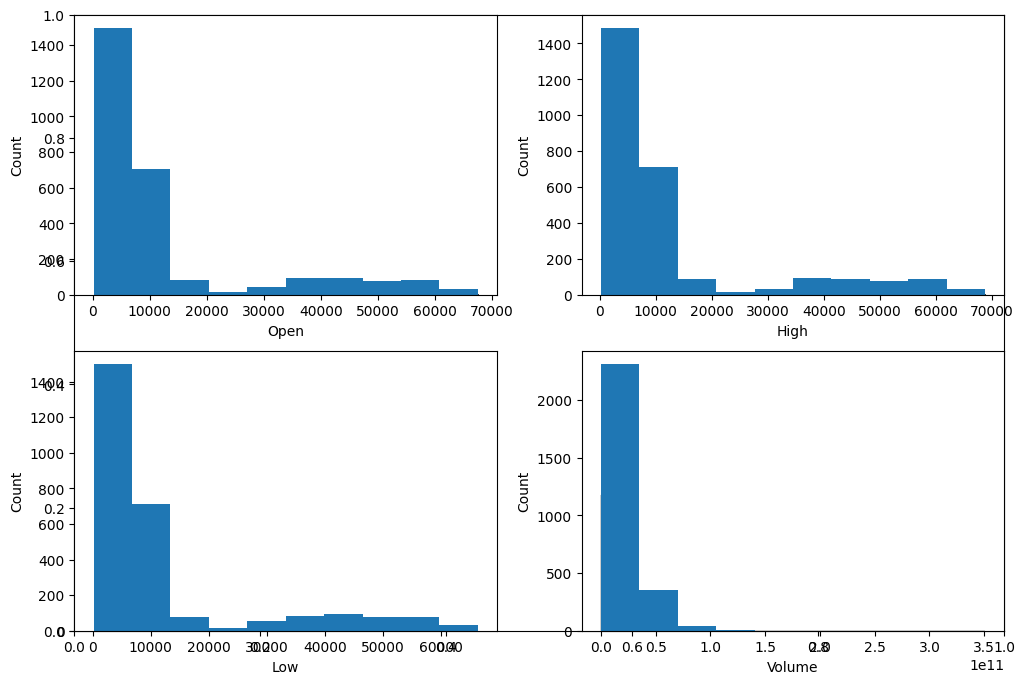

In [33]:
features = ['Open', 'High', 'Low', 'Volume']
plt.subplots(figsize = (12, 8))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col])
    plt.hist(df[col])
plt.show()

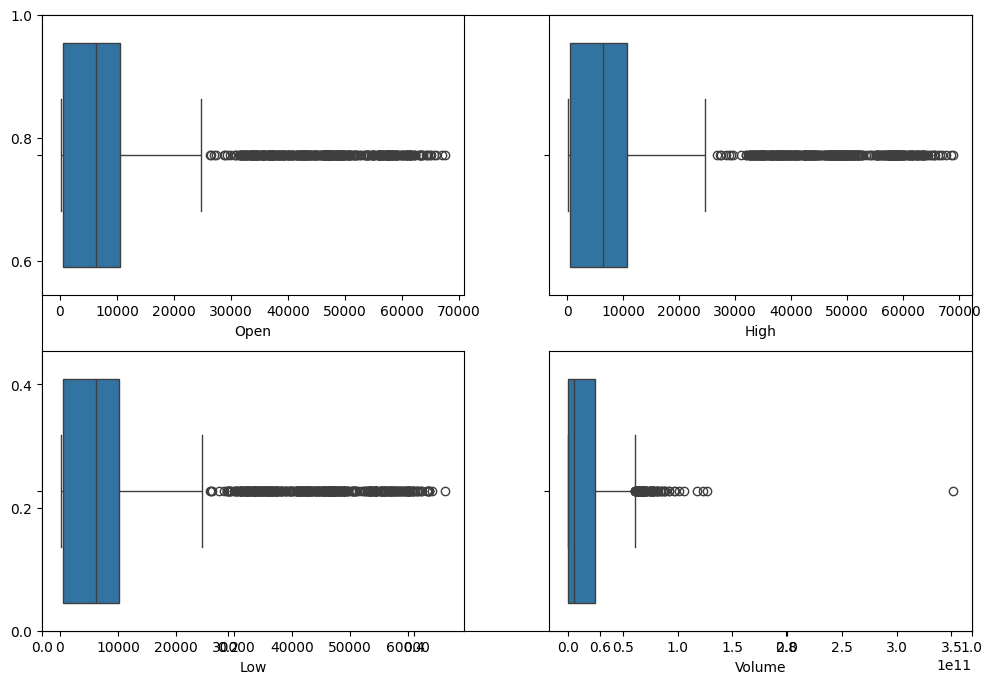

In [34]:
#boxplotting the features
features = ['Open', 'High', 'Low', 'Volume']
plt.subplots(figsize = (12, 8))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(df[col], orient='h')

plt.show()


In [35]:
#printing the format of date column
print(df['Date'].dtype)
print('Since the datetime conversion is already done, we dont need to do it again')

object
Since the datetime conversion is already done, we dont need to do it again


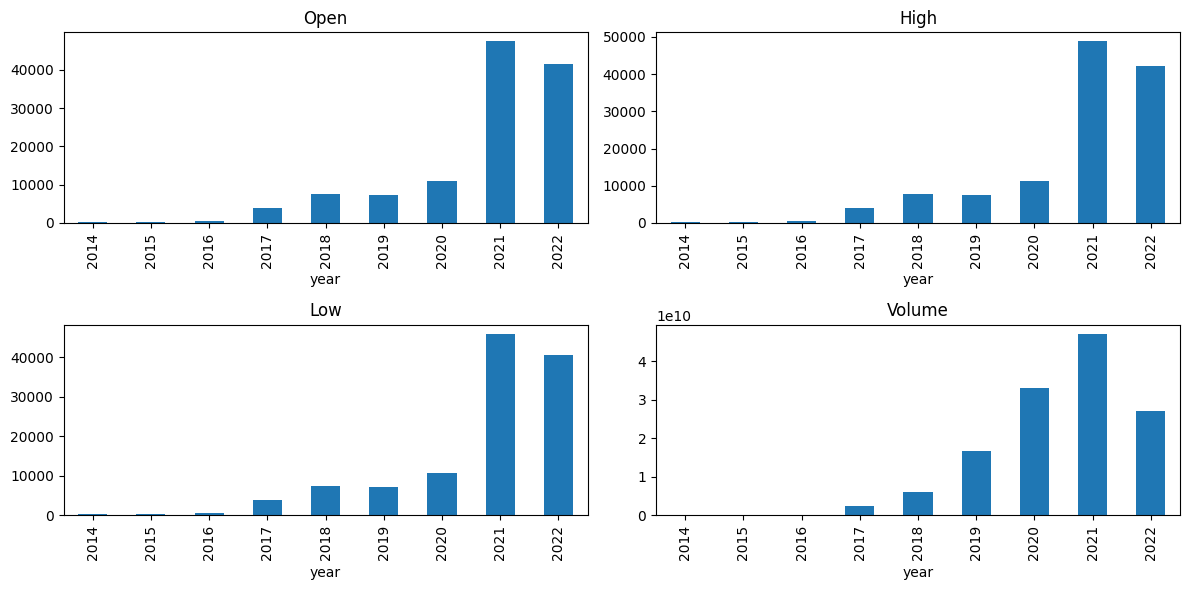

In [38]:
#barplot creation
data_grouped = df.groupby('year')[features].mean()
plt.figure(figsize=(12, 6))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    data_grouped[col].plot.bar()
    plt.title(col)

plt.tight_layout()
plt.show()


In [39]:
splitted = df['Date'].str.split('-', expand=True)

df['year'] = splitted[0].astype('int')
df['month'] = splitted[1].astype('int')
df['day'] = splitted[2].astype('int')

In [40]:
df['is_quarter_end'] = np.where(df['month'] % 3 == 0, 1, 0)
df.head()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,1
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1


In [41]:
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)


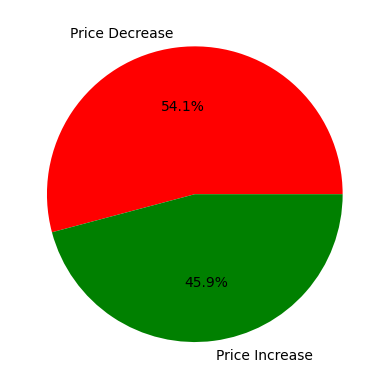

In [42]:
plt.pie(df['target'].value_counts().values,
        labels=['Price Decrease', 'Price Increase'],
        autopct='%1.1f%%',
        colors=['red', 'green']
        )
plt.show()

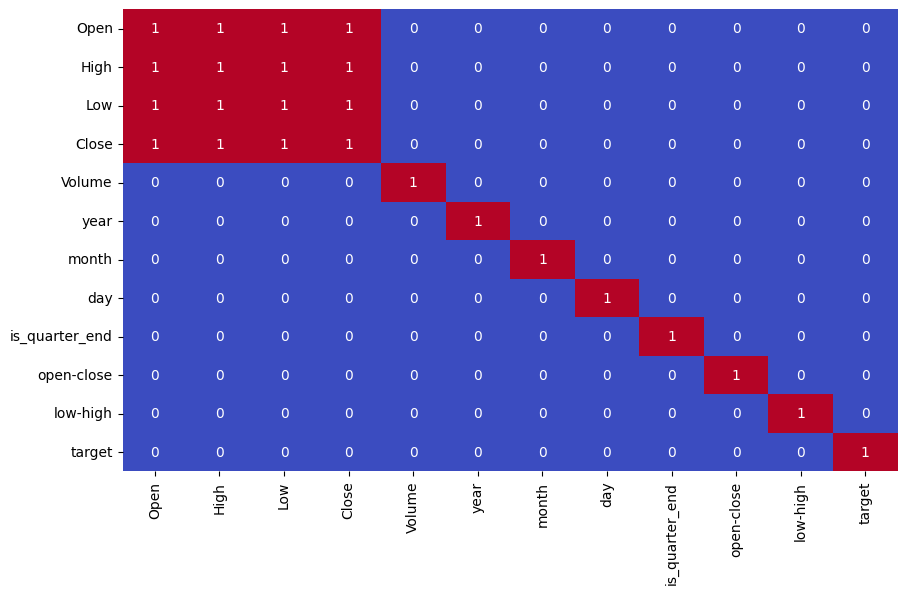

In [44]:
#plotting correlation heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(numeric_only=True) > 0.9,
            annot = True,
            cmap = 'coolwarm',
            cbar= False)

plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#assuming df is already defined
features = df[['Open', 'High', 'Low', 'Volume', 'is_quarter_end', 'open-close', 'low-high']]
target = df['target']

#scaling the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

#train-test split
x_train, x_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)


Training set shape: (2170, 7)
Test set shape: (543, 7)


In [49]:
#model development and evaluation
models = [LogisticRegression(),
          SVC(kernel='poly', probability=True),
          XGBClassifier(),
          ]

for model in models:
    model.fit(x_train, y_train)
    print(f"{model.__class__.__name__} trained successfully.")

    train_acc = metrics.roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    print(f"Training AUC: {train_acc:.4f}")

    test_acc = metrics.roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    print(f"Test AUC: {test_acc:.4f}\n")

    print()

LogisticRegression trained successfully.
Training AUC: 0.5271
Test AUC: 0.4978


SVC trained successfully.
Training AUC: 0.5391
Test AUC: 0.5033


XGBClassifier trained successfully.
Training AUC: 0.9927
Test AUC: 0.5277




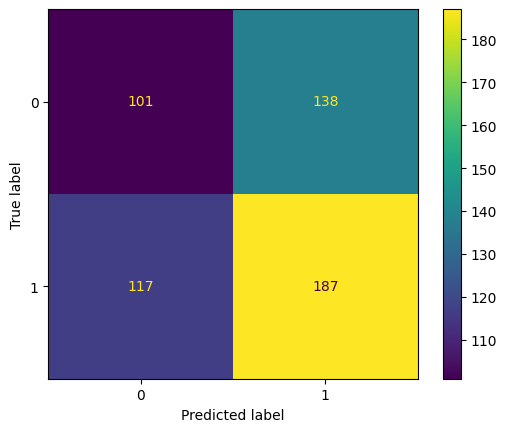

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.show()